In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import xgboost
import lightgbm
import imblearn

print("Everything is working!")
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)


Everything is working!
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [28]:
print("Dataset dimensions:", df.shape)
print("Number of customers:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset dimensions: (7043, 21)
Number of customers: 7043
Number of columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [30]:
print("Data types:")
display(df.dtypes.to_frame(name="Data Type"))

Data types:


,Data Type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


In [31]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

blank_total_charges = df["TotalCharges"].str.strip().eq("")

print("Number of blank/whitespace values in TotalCharges:",
      blank_total_charges.sum())

display(df.loc[
    blank_total_charges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

TotalCharges data type: str
Number of blank/whitespace values in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [32]:
# Standard missing values (NaN)
missing_values = df.isna().sum()

print("Standard missing values:")
display(
    missing_values[missing_values > 0]
    .to_frame(name="Missing Count")
)

Standard missing values:


,Missing Count


In [33]:
# Empty or whitespace-only values in string columns
string_columns = df.select_dtypes(include="str").columns

whitespace_counts = {}

for column in string_columns:
    count = df[column].str.strip().eq("").sum()
    if count > 0:
        whitespace_counts[column] = count

print("Empty/whitespace values in string columns:")
print(whitespace_counts)

Empty/whitespace values in string columns:
{'TotalCharges': np.int64(11)}


In [34]:
unique_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique()
})

display(unique_summary)

,Data Type,Unique Values
customerID,str,7043
gender,str,2
SeniorCitizen,int64,2
Partner,str,2
Dependents,str,2
tenure,int64,73
PhoneService,str,2
MultipleLines,str,3
InternetService,str,3
OnlineSecurity,str,3


In [35]:
for column in df.columns:
    if df[column].nunique() <= 10:
        print(f"{column}: {df[column].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen: [0 1]
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Month-to-

In [36]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

eda_numerical = pd.DataFrame({
    "tenure": df["tenure"],
    "MonthlyCharges": df["MonthlyCharges"],
    "TotalCharges": total_charges_numeric
})

display(eda_numerical.describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [37]:
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

churn_distribution = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages
})

display(churn_distribution)

,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


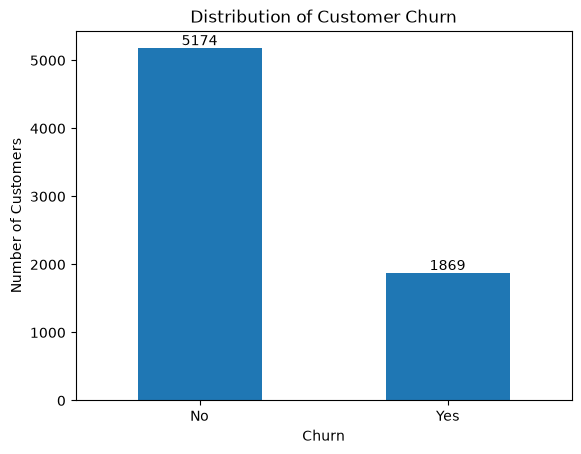

In [38]:
ax = churn_counts.plot(kind="bar")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

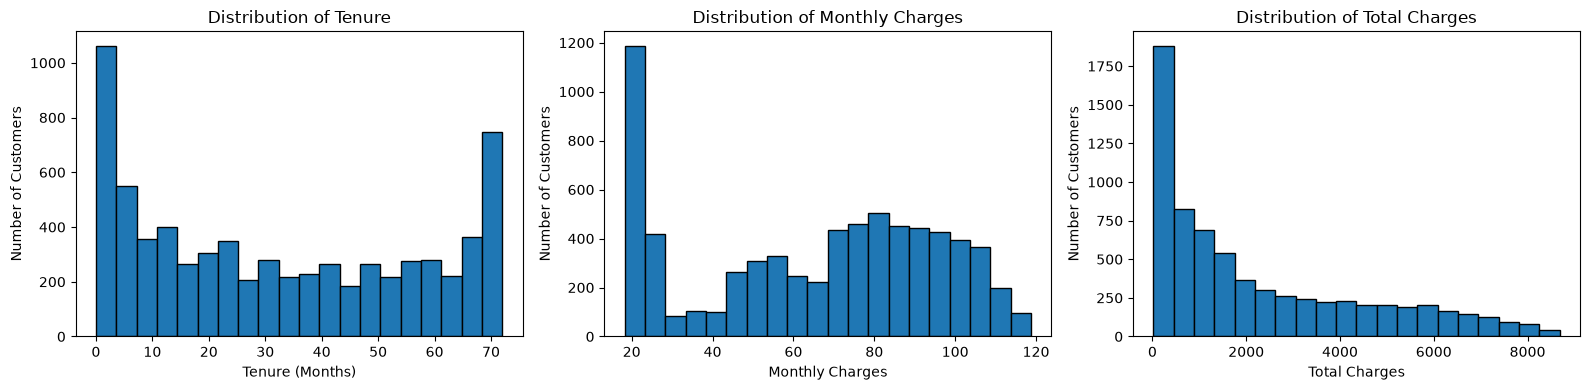

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(eda_numerical["tenure"], bins=20, edgecolor="black")
axes[0].set_title("Distribution of Tenure")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(eda_numerical["MonthlyCharges"], bins=20, edgecolor="black")
axes[1].set_title("Distribution of Monthly Charges")
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Number of Customers")

axes[2].hist(
    eda_numerical["TotalCharges"].dropna(),
    bins=20,
    edgecolor="black"
)
axes[2].set_title("Distribution of Total Charges")
axes[2].set_xlabel("Total Charges")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [40]:
eda_with_churn = eda_numerical.copy()
eda_with_churn["Churn"] = df["Churn"]

numerical_by_churn = eda_with_churn.groupby("Churn").agg(
    {
        "tenure": ["mean", "median"],
        "MonthlyCharges": ["mean", "median"],
        "TotalCharges": ["mean", "median"]
    }
)

display(numerical_by_churn.round(2))

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2555.34  1683.60
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

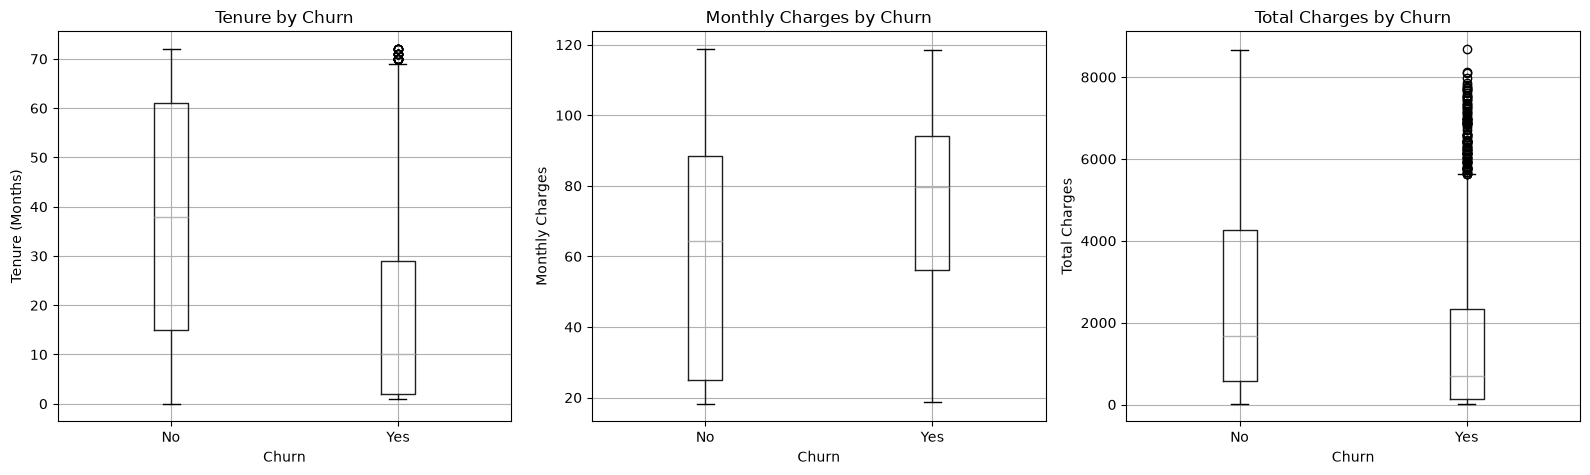

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

eda_with_churn.boxplot(column="tenure", by="Churn", ax=axes[0])
axes[0].set_title("Tenure by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Tenure (Months)")

eda_with_churn.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

eda_with_churn.boxplot(column="TotalCharges", by="Churn", ax=axes[2])
axes[2].set_title("Total Charges by Churn")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Total Charges")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [42]:
categorical_results = []

for feature in categorical_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    for category, rate in churn_rate.items():
        categorical_results.append({
            "Feature": feature,
            "Category": category,
            "Churn Rate (%)": round(rate, 2)
        })

categorical_churn_table = pd.DataFrame(categorical_results)

display(categorical_churn_table)

,Feature,Category,Churn Rate (%)
0,gender,Female,26.92
1,gender,Male,26.16
2,SeniorCitizen,0,23.61
3,SeniorCitizen,1,41.68
4,Partner,No,32.96
5,Partner,Yes,19.66
6,Dependents,No,31.28
7,Dependents,Yes,15.45
8,PhoneService,No,24.93
9,PhoneService,Yes,26.71


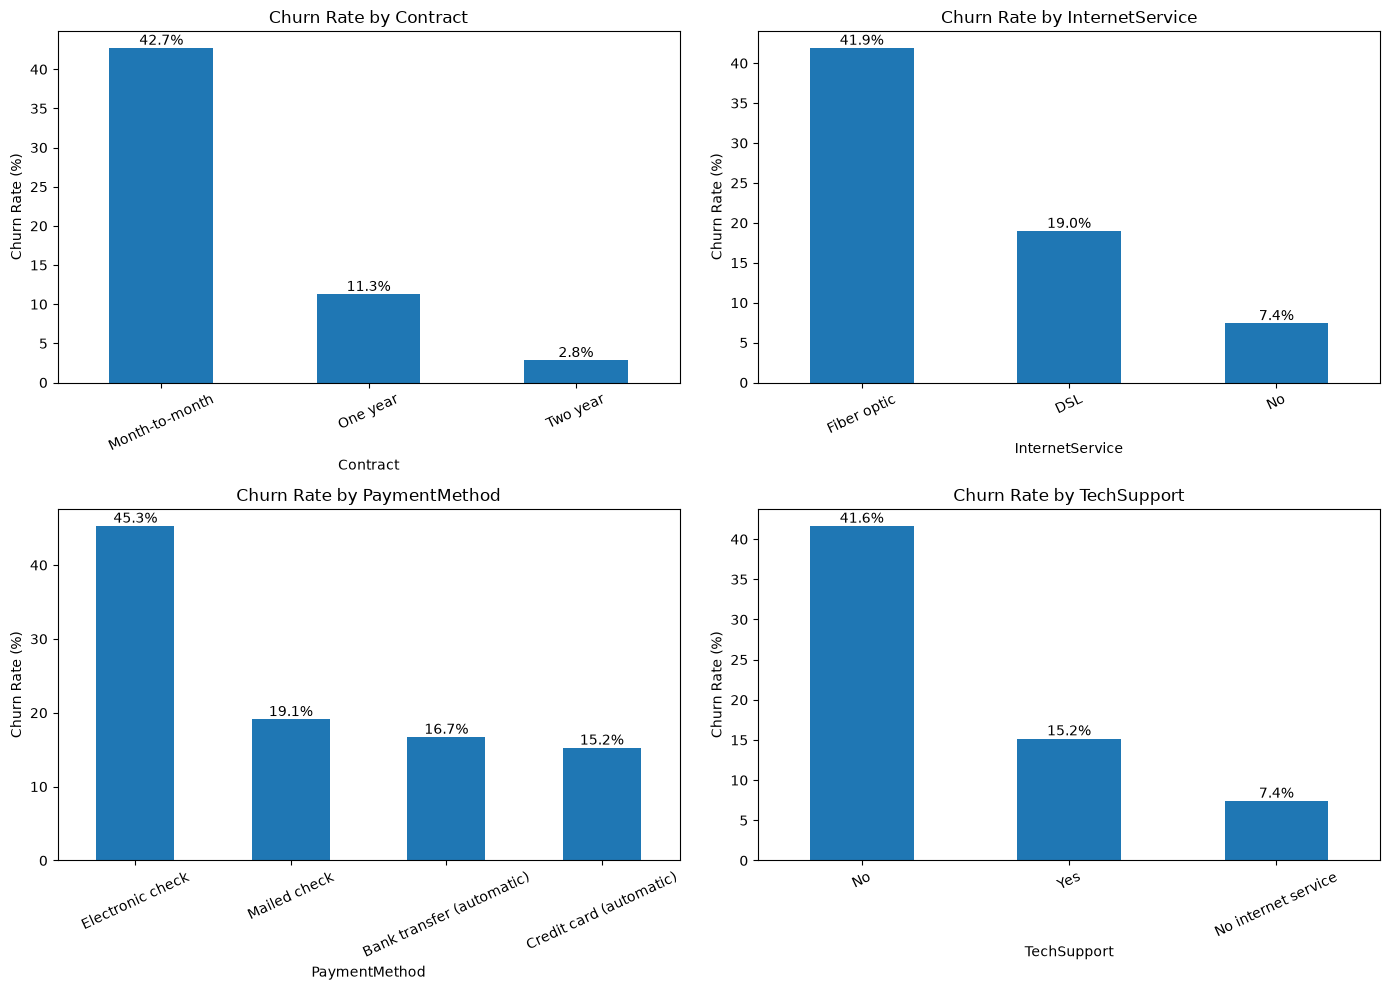

In [43]:
selected_categorical = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for feature, ax in zip(selected_categorical, axes.flatten()):

    rates = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    rates.plot(kind="bar", ax=ax)

    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=25)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

In [44]:
correlation_matrix = eda_numerical.corr()

display(correlation_matrix.round(3))

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


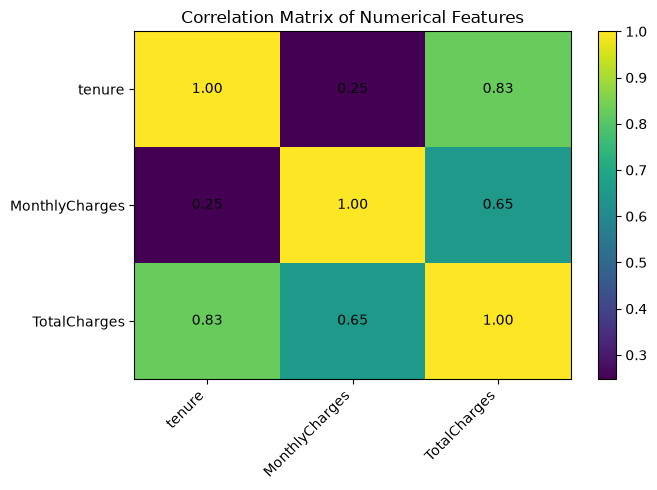

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Features")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [46]:
outlier_summary = []

for column in ["tenure", "MonthlyCharges", "TotalCharges"]:
    data = eda_numerical[column].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(data) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0


In [47]:
df_model = df.copy()

df_model = df_model.drop(columns=["customerID"])

In [48]:
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"],
    errors="coerce"
)

In [49]:
print(df_model.shape)
print(df_model["TotalCharges"].dtype)
print("Missing TotalCharges:", df_model["TotalCharges"].isna().sum())

(7043, 20)
float64
Missing TotalCharges: 11


In [50]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [51]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total predictors:", len(numerical_features) + len(categorical_features))

Numerical features: 3
Categorical features: 16
Total predictors: 19


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [53]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [54]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'P

In [55]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print("Target values:", y.unique())
print("\nTarget distribution:")
print(y.value_counts())

Target values: [0 1]

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Training set:
X_train shape: (5634, 19)
y_train shape: (5634,)

Testing set:
X_test shape: (1409, 19)
y_test shape: (1409,)


In [57]:
print("Original dataset:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTraining set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Original dataset:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Training set:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing set:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [58]:
X_train_processed = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Number of processed features:", len(feature_names))

Original training shape: (5634, 19)
Processed training shape: (5634, 46)
Number of processed features: 46


In [59]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": feature_names,
    "MI Score": mi_scores
}).sort_values(
    by="MI Score",
    ascending=False
)

display(mi_results.head(15))

,Feature,MI Score
37,cat__Contract_Month-to-month,0.083843
0,num__tenure,0.065928
39,cat__Contract_Two year,0.060891
28,cat__TechSupport_No,0.059446
19,cat__OnlineSecurity_No,0.057975
17,cat__InternetService_Fiber optic,0.046310
1,num__MonthlyCharges,0.045110
44,cat__PaymentMethod_Electronic check,0.044007
2,num__TotalCharges,0.039060
26,cat__DeviceProtection_No internet service,0.036680


In [60]:
l1_model = LogisticRegression(
    solver="liblinear",
    l1_ratio=1.0,
    C=1.0,
    random_state=42,
    max_iter=1000
)

l1_model.fit(X_train_processed, y_train)

l1_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": l1_model.coef_[0],
    "Abs Coefficient": np.abs(l1_model.coef_[0])
}).sort_values(
    by="Abs Coefficient",
    ascending=False
)

display(l1_results.head(15))

print(
    "Number of non-zero features:",
    (l1_model.coef_[0] != 0).sum()
)

print(
    "Number of zero features:",
    (l1_model.coef_[0] == 0).sum()
)

,Feature,Coefficient,Abs Coefficient
39,cat__Contract_Two year,-1.349390,1.349390
0,num__tenure,-1.230092,1.230092
38,cat__Contract_One year,-0.691640,0.691640
26,cat__DeviceProtection_No internet service,-0.601217,0.601217
2,num__TotalCharges,0.501515,0.501515
17,cat__InternetService_Fiber optic,0.482272,0.482272
20,cat__OnlineSecurity_No internet service,-0.482179,0.482179
21,cat__OnlineSecurity_Yes,-0.420289,0.420289
40,cat__PaperlessBilling_No,-0.373384,0.373384
30,cat__TechSupport_Yes,-0.369794,0.369794


Number of non-zero features: 33
Number of zero features: 13


In [61]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

# Fresh leakage-safe preprocessing
numerical_pipeline_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_fs = Pipeline(steps=[
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_fs = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_fs, numerical_features),
        ("cat", categorical_pipeline_fs, categorical_features)
    ]
)

In [62]:
def mixed_mutual_info(X, y):
    n_num = len(numerical_features)

    discrete_mask = np.array(
        [False] * n_num +
        [True] * (X.shape[1] - n_num)
    )

    return mutual_info_classif(
        X,
        y,
        discrete_features=discrete_mask,
        random_state=42
    )

In [63]:
outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [64]:
all_features_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LogisticRegression(
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

all_results = cross_validate(
    all_features_pipeline,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

In [65]:
mi_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("selector", SelectKBest(
        score_func=mixed_mutual_info
    )),

    ("model", LogisticRegression(
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

In [66]:
mi_param_grid = {
    "selector__k": [10, 15, 20, 25, 30, 35, 40]
}

In [67]:
mi_search = GridSearchCV(
    estimator=mi_pipeline,
    param_grid=mi_param_grid,
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=1
)

In [68]:
mi_results = cross_validate(
    mi_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1
)

In [69]:
l1_selector = SelectFromModel(
    LogisticRegression(
        solver="liblinear",
        l1_ratio=1.0,
        C=1.0,
        max_iter=1000,
        random_state=42
    )
)

l1_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("selector", l1_selector),

    ("model", LogisticRegression(
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

l1_results = cross_validate(
    l1_pipeline,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1
)

In [70]:
def summarize_cv(results, name):
    return {
        "Method": name,

        "Accuracy Mean": results["test_accuracy"].mean(),
        "Accuracy Std": results["test_accuracy"].std(),

        "Precision Mean": results["test_precision"].mean(),
        "Recall Mean": results["test_recall"].mean(),
        "F1 Mean": results["test_f1"].mean(),

        "ROC-AUC Mean": results["test_roc_auc"].mean(),
        "ROC-AUC Std": results["test_roc_auc"].std()
    }


feature_selection_comparison = pd.DataFrame([
    summarize_cv(all_results, "All Features"),
    summarize_cv(mi_results, "Mutual Information"),
    summarize_cv(l1_results, "L1 Selection")
])

display(
    feature_selection_comparison.round(4)
)

,Method,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,All Features,0.8021,0.0120,0.6530,0.5431,0.5923,0.8461,0.0125
1,Mutual Information,0.8026,0.0127,0.6539,0.5452,0.5939,0.8464,0.0126
2,L1 Selection,0.8028,0.0124,0.6547,0.5445,0.5938,0.8460,0.0125


In [71]:
selected_k_values = [
    estimator.best_params_["selector__k"]
    for estimator in mi_results["estimator"]
]

print("MI selected k in each outer fold:")
print(selected_k_values)

print(
    "Most common selected k:",
    pd.Series(selected_k_values).mode()[0]
)

MI selected k in each outer fold:
[40, 40, 40, 40, 40]
Most common selected k: 40


In [72]:
l1_selected_counts = []

for estimator in l1_results["estimator"]:

    selector = estimator.named_steps["selector"]

    selected_count = selector.get_support().sum()

    l1_selected_counts.append(selected_count)

print("L1 selected features in each fold:")
print(l1_selected_counts)

print(
    "Average selected features:",
    np.mean(l1_selected_counts)
)

L1 selected features in each fold:
[np.int64(33), np.int64(31), np.int64(31), np.int64(32), np.int64(32)]
Average selected features: 31.8


In [73]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", DummyClassifier(
        strategy="most_frequent"
    ))
])

In [74]:
baseline_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [75]:
baseline_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Mean": [
        baseline_results["test_accuracy"].mean(),
        baseline_results["test_precision"].mean(),
        baseline_results["test_recall"].mean(),
        baseline_results["test_f1"].mean(),
        baseline_results["test_roc_auc"].mean()
    ],

    "Std": [
        baseline_results["test_accuracy"].std(),
        baseline_results["test_precision"].std(),
        baseline_results["test_recall"].std(),
        baseline_results["test_f1"].std(),
        baseline_results["test_roc_auc"].std()
    ]
})

display(baseline_summary.round(4))

,Metric,Mean,Std
0,Accuracy,0.7346,0.0001
1,Precision,0.0000,0.0000
2,Recall,0.0000,0.0000
3,F1-score,0.0000,0.0000
4,ROC-AUC,0.5000,0.0000


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [77]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

In [78]:
model_results = {}

for name, model in models.items():

    print(f"Evaluating: {name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_fs),
        ("model", model)
    ])

    results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=1
    )

    model_results[name] = results

print("\nAll models evaluated successfully.")

Evaluating: Logistic Regression...
Evaluating: SVM...


c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py

Evaluating: Random Forest...
Evaluating: XGBoost...
Evaluating: LightGBM...

All models evaluated successfully.


In [79]:
comparison_rows = []

for name, results in model_results.items():
    comparison_rows.append({
        "Model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Precision": results["test_precision"].mean(),
        "Recall": results["test_recall"].mean(),
        "F1-score": results["test_f1"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean(),
        "ROC-AUC Std": results["test_roc_auc"].std()
    })

model_comparison = pd.DataFrame(comparison_rows)

model_comparison = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,ROC-AUC Std
0,Logistic Regression,0.8026,0.6547,0.5431,0.5930,0.8461,0.0125
4,LightGBM,0.7943,0.6428,0.5064,0.5663,0.8378,0.0087
3,XGBoost,0.7842,0.6137,0.5057,0.5544,0.8229,0.0084
2,Random Forest,0.7843,0.6237,0.4749,0.5387,0.8177,0.0114
1,SVM,0.8051,0.6820,0.4990,0.5761,0.7989,0.0181


In [80]:
baseline_row = pd.DataFrame([{
    "Model": "Dummy Baseline",
    "Accuracy": baseline_results["test_accuracy"].mean(),
    "Precision": baseline_results["test_precision"].mean(),
    "Recall": baseline_results["test_recall"].mean(),
    "F1-score": baseline_results["test_f1"].mean(),
    "ROC-AUC": baseline_results["test_roc_auc"].mean(),
    "ROC-AUC Std": baseline_results["test_roc_auc"].std()
}])

full_comparison = pd.concat(
    [model_comparison, baseline_row],
    ignore_index=True
)

full_comparison = full_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(full_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,ROC-AUC Std
0,Logistic Regression,0.8026,0.6547,0.5431,0.5930,0.8461,0.0125
1,LightGBM,0.7943,0.6428,0.5064,0.5663,0.8378,0.0087
2,XGBoost,0.7842,0.6137,0.5057,0.5544,0.8229,0.0084
3,Random Forest,0.7843,0.6237,0.4749,0.5387,0.8177,0.0114
4,SVM,0.8051,0.6820,0.4990,0.5761,0.7989,0.0181
5,Dummy Baseline,0.7346,0.0000,0.0000,0.0000,0.5000,0.0000


In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=outer_cv,
    n_jobs=1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("\nBest Logistic Regression CV ROC-AUC:")
print(round(logistic_grid.best_score_, 4))

Best Logistic Regression parameters:
{'model__C': 10, 'model__solver': 'liblinear'}

Best Logistic Regression CV ROC-AUC:
0.8463


In [82]:
logistic_tuning_results = pd.DataFrame(
    logistic_grid.cv_results_
)[[
    "param_model__C",
    "param_model__solver",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]]

logistic_tuning_results = logistic_tuning_results.sort_values(
    "mean_test_score",
    ascending=False
)

display(logistic_tuning_results.round(4))

,param_model__C,param_model__solver,mean_test_score,std_test_score,mean_train_score
6,10.00,liblinear,0.8463,0.0128,0.8499
7,10.00,lbfgs,0.8463,0.0127,0.8499
8,100.00,liblinear,0.8463,0.0129,0.8499
9,100.00,lbfgs,0.8463,0.0129,0.8499
5,1.00,lbfgs,0.8461,0.0125,0.8496
4,1.00,liblinear,0.8461,0.0125,0.8495
3,0.10,lbfgs,0.8455,0.0119,0.8485
2,0.10,liblinear,0.8454,0.0119,0.8485
0,0.01,liblinear,0.8436,0.0110,0.8456
1,0.01,lbfgs,0.8435,0.0111,0.8457


In [83]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

lightgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

lightgbm_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [7, 15, 31, 63],
    "model__max_depth": [-1, 3, 5, 7],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0]
}

lightgbm_search = RandomizedSearchCV(
    estimator=lightgbm_pipeline,
    param_distributions=lightgbm_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=outer_cv,
    random_state=42,
    n_jobs=1,
    return_train_score=True
)

lightgbm_search.fit(X_train, y_train)

print("Best LightGBM parameters:")
print(lightgbm_search.best_params_)

print("\nBest LightGBM CV ROC-AUC:")
print(round(lightgbm_search.best_score_, 4))

Best LightGBM parameters:
{'model__subsample': 0.7, 'model__num_leaves': 7, 'model__n_estimators': 500, 'model__min_child_samples': 20, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

Best LightGBM CV ROC-AUC:
0.8489


In [84]:
lightgbm_tuning_results = pd.DataFrame(
    lightgbm_search.cv_results_
)[[
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]]

lightgbm_tuning_results = lightgbm_tuning_results.sort_values(
    "mean_test_score",
    ascending=False
)

display(lightgbm_tuning_results.head(10).round(4))

,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,mean_test_score,std_test_score,mean_train_score
16,500,0.01,7,3,20,0.70,1.00,0.8489,0.0110,0.8674
10,100,0.05,15,-1,50,1.00,0.70,0.8487,0.0112,0.8900
6,300,0.01,63,5,20,0.85,0.70,0.8487,0.0108,0.8918
0,200,0.03,63,3,50,0.85,1.00,0.8485,0.0116,0.8706
5,300,0.01,7,-1,30,0.85,1.00,0.8483,0.0111,0.8629
11,100,0.03,7,-1,10,0.85,0.70,0.8482,0.0121,0.8625
8,100,0.10,63,3,10,0.85,0.85,0.8480,0.0115,0.8812
19,300,0.01,7,3,30,0.85,0.85,0.8475,0.0112,0.8611
15,100,0.05,63,5,20,1.00,0.85,0.8473,0.0108,0.9044
12,500,0.03,7,-1,10,0.85,1.00,0.8463,0.0115,0.8987


In [85]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

balanced_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LogisticRegression(
        C=10,
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

balanced_logistic_results = cross_validate(
    balanced_logistic,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

print("Balanced Logistic Regression:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean = balanced_logistic_results[f"test_{metric}"].mean()
    std = balanced_logistic_results[f"test_{metric}"].std()

    print(
        f"{metric.capitalize():10s}: "
        f"{mean:.4f} ± {std:.4f}"
    )

Balanced Logistic Regression:
Accuracy  : 0.7481 ± 0.0157
Precision : 0.5164 ± 0.0193
Recall    : 0.8000 ± 0.0379
F1        : 0.6275 ± 0.0241
Roc_auc   : 0.8462 ± 0.0127


In [86]:
from lightgbm import LGBMClassifier

balanced_lightgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

balanced_lightgbm_results = cross_validate(
    balanced_lightgbm,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

print("Balanced LightGBM:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean = balanced_lightgbm_results[f"test_{metric}"].mean()
    std = balanced_lightgbm_results[f"test_{metric}"].std()

    print(
        f"{metric.capitalize():10s}: "
        f"{mean:.4f} ± {std:.4f}"
    )

Balanced LightGBM:
Accuracy  : 0.7510 ± 0.0118
Precision : 0.5199 ± 0.0149
Recall    : 0.8067 ± 0.0270
F1        : 0.6322 ± 0.0176
Roc_auc   : 0.8483 ± 0.0116


In [87]:
# Task 8 - Final Class Imbalance Comparison

imbalance_comparison = pd.DataFrame([
    {
        "Model": "Tuned Logistic",
        "Accuracy": logistic_grid.cv_results_[
            "mean_test_score"
        ][logistic_grid.best_index_],  # سنستبدلها أدناه بالمقاييس الكاملة
    }
])

In [88]:
# ==========================================
# TASK 8 - CLASS IMBALANCE FINAL COMPARISON
# ==========================================

# 1. Tuned Logistic Regression (without class weighting)
tuned_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),
    ("model", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

tuned_logistic_results = cross_validate(
    tuned_logistic,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)


# 2. Tuned LightGBM (without class weighting)
tuned_lightgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),
    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

tuned_lightgbm_results = cross_validate(
    tuned_lightgbm,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)


# Function to extract mean CV metrics
def get_cv_metrics(name, results):
    return {
        "Model": name,
        "Accuracy": results["test_accuracy"].mean(),
        "Precision": results["test_precision"].mean(),
        "Recall": results["test_recall"].mean(),
        "F1-score": results["test_f1"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean()
    }


# Build comparison table
imbalance_comparison = pd.DataFrame([
    get_cv_metrics(
        "Tuned Logistic",
        tuned_logistic_results
    ),

    get_cv_metrics(
        "Balanced Logistic",
        balanced_logistic_results
    ),

    get_cv_metrics(
        "Tuned LightGBM",
        tuned_lightgbm_results
    ),

    get_cv_metrics(
        "Balanced LightGBM",
        balanced_lightgbm_results
    )
])

display(imbalance_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic,0.8037,0.6557,0.5485,0.5968,0.8463
1,Balanced Logistic,0.7481,0.5164,0.8000,0.6275,0.8462
2,Tuned LightGBM,0.8051,0.6765,0.5104,0.5814,0.8489
3,Balanced LightGBM,0.7510,0.5199,0.8067,0.6322,0.8483


In [89]:
# ==========================================
# TASK 9 - FINAL MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Fit both final candidates using the full training set
tuned_lightgbm.fit(X_train, y_train)
balanced_lightgbm.fit(X_train, y_train)

print("Final candidate models trained successfully.")

Final candidate models trained successfully.


In [90]:
# Tuned LightGBM
y_pred_tuned = tuned_lightgbm.predict(X_test)
y_prob_tuned = tuned_lightgbm.predict_proba(X_test)[:, 1]

# Balanced LightGBM
y_pred_balanced = balanced_lightgbm.predict(X_test)
y_prob_balanced = balanced_lightgbm.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [91]:
def final_metrics(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }


final_comparison = pd.DataFrame([
    final_metrics(
        "Tuned LightGBM",
        y_test,
        y_pred_tuned,
        y_prob_tuned
    ),

    final_metrics(
        "Balanced LightGBM",
        y_test,
        y_pred_balanced,
        y_prob_balanced
    )
])

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned LightGBM,0.8062,0.6747,0.5214,0.5882,0.8473
1,Balanced LightGBM,0.7480,0.5162,0.8075,0.6298,0.8464


In [92]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Tuned LightGBM Confusion Matrix:")
print(cm_tuned)

print("\nBalanced LightGBM Confusion Matrix:")
print(cm_balanced)

Tuned LightGBM Confusion Matrix:
[[941  94]
 [179 195]]

Balanced LightGBM Confusion Matrix:
[[752 283]
 [ 72 302]]


In [93]:
print("Tuned LightGBM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Churn", "Churn"]
    )
)

print("\nBalanced LightGBM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["No Churn", "Churn"]
    )
)

Tuned LightGBM Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Balanced LightGBM Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [94]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),
    ("model", SVC())
])

svm_param_dist = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_search = RandomizedSearchCV(
    estimator=svm_tuning_pipeline,
    param_distributions=svm_param_dist,
    n_iter=12,
    scoring="roc_auc",
    cv=outer_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

svm_search.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_search.best_params_)

print("\nBest SVM CV ROC-AUC:")
print(round(svm_search.best_score_, 4))

Best SVM parameters:
{'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__C': 0.1}

Best SVM CV ROC-AUC:
0.8362


In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 20]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=outer_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(round(rf_search.best_score_, 4))

Best Random Forest parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_depth': 5}

Best Random Forest CV ROC-AUC:
0.8458


In [96]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

xgb_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=outer_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV ROC-AUC:")
print(round(xgb_search.best_score_, 4))

Best XGBoost parameters:
{'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.03}

Best XGBoost CV ROC-AUC:
0.8499


In [97]:
# ==========================================
# TASK 7 - FINAL TUNING COMPARISON
# ==========================================

tuning_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Before Tuning ROC-AUC": [
        0.8461,
        0.7989,
        0.8177,
        0.8229,
        0.8378
    ],

    "After Tuning ROC-AUC": [
        logistic_grid.best_score_,
        svm_search.best_score_,
        rf_search.best_score_,
        xgb_search.best_score_,
        lightgbm_search.best_score_
    ]
})

tuning_summary["Improvement"] = (
    tuning_summary["After Tuning ROC-AUC"]
    - tuning_summary["Before Tuning ROC-AUC"]
)

tuning_summary = tuning_summary.sort_values(
    "After Tuning ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(tuning_summary.round(4))

,Model,Before Tuning ROC-AUC,After Tuning ROC-AUC,Improvement
0,XGBoost,0.8229,0.8499,0.0270
1,LightGBM,0.8378,0.8489,0.0111
2,Logistic Regression,0.8461,0.8463,0.0002
3,Random Forest,0.8177,0.8458,0.0281
4,SVM,0.7989,0.8362,0.0373


In [98]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate

smote_lightgbm = ImbPipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

smote_lightgbm_results = cross_validate(
    smote_lightgbm,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

print("SMOTE LightGBM:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean = smote_lightgbm_results[f"test_{metric}"].mean()
    std = smote_lightgbm_results[f"test_{metric}"].std()

    print(
        f"{metric.capitalize():10s}: "
        f"{mean:.4f} ± {std:.4f}"
    )

SMOTE LightGBM:
Accuracy  : 0.7749 ± 0.0124
Precision : 0.5581 ± 0.0194
Recall    : 0.7344 ± 0.0227
F1        : 0.6340 ± 0.0176
Roc_auc   : 0.8456 ± 0.0114


In [99]:
smote_comparison = pd.DataFrame([
    get_cv_metrics(
        "Tuned LightGBM",
        tuned_lightgbm_results
    ),

    get_cv_metrics(
        "Balanced LightGBM",
        balanced_lightgbm_results
    ),

    get_cv_metrics(
        "SMOTE LightGBM",
        smote_lightgbm_results
    )
])

display(smote_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned LightGBM,0.8051,0.6765,0.5104,0.5814,0.8489
1,Balanced LightGBM,0.7510,0.5199,0.8067,0.6322,0.8483
2,SMOTE LightGBM,0.7749,0.5581,0.7344,0.6340,0.8456


In [100]:
# ==========================================
# TASK 9 - CROSS-VALIDATION & METRIC SELECTION
# ==========================================

from sklearn.model_selection import cross_validate

# Best tuned pipelines from Task 7
best_models_task9 = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_,
    "LightGBM": lightgbm_search.best_estimator_
}

task9_results = []

for name, model in best_models_task9.items():

    print(f"Evaluating: {name}...")

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=1
    )

    task9_results.append({
        "Model": name,

        "Accuracy Mean":
            cv_results["test_accuracy"].mean(),
        "Accuracy Std":
            cv_results["test_accuracy"].std(),

        "Precision Mean":
            cv_results["test_precision"].mean(),
        "Precision Std":
            cv_results["test_precision"].std(),

        "Recall Mean":
            cv_results["test_recall"].mean(),
        "Recall Std":
            cv_results["test_recall"].std(),

        "F1 Mean":
            cv_results["test_f1"].mean(),
        "F1 Std":
            cv_results["test_f1"].std(),

        "ROC-AUC Mean":
            cv_results["test_roc_auc"].mean(),
        "ROC-AUC Std":
            cv_results["test_roc_auc"].std()
    })


task9_table = pd.DataFrame(task9_results)

task9_table = task9_table.sort_values(
    "ROC-AUC Mean",
    ascending=False
).reset_index(drop=True)

display(task9_table.round(4))

Evaluating: Logistic Regression...
Evaluating: SVM...
Evaluating: Random Forest...
Evaluating: XGBoost...
Evaluating: LightGBM...


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,XGBoost,0.8048,0.0100,0.6718,0.0270,0.5177,0.0213,0.5846,0.0206,0.8499,0.0117
1,LightGBM,0.8051,0.0079,0.6765,0.0237,0.5104,0.0242,0.5814,0.0188,0.8489,0.0110
2,Logistic Regression,0.8037,0.0125,0.6557,0.0275,0.5485,0.0387,0.5968,0.0297,0.8463,0.0128
3,Random Forest,0.7980,0.0080,0.6972,0.0333,0.4247,0.0184,0.5273,0.0165,0.8458,0.0103
4,SVM,0.7991,0.0079,0.6730,0.0282,0.4749,0.0225,0.5563,0.0172,0.8362,0.0132


In [101]:
# ==========================================
# TASK 10 - TOP 3 MODELS: TEST PREDICTIONS
# ==========================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

top3_models = {
    "XGBoost": xgb_search.best_estimator_,
    "LightGBM": lightgbm_search.best_estimator_,
    "Logistic Regression": logistic_grid.best_estimator_
}

top3_predictions = {}

for name, model in top3_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Probability of the positive class (Churn = 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    top3_predictions[name] = {
        "model": model,
        "pred": y_pred,
        "prob": y_prob,
        "auc": roc_auc_score(y_test, y_prob),
        "cm": confusion_matrix(y_test, y_pred)
    }

    print(f"{name} Test ROC-AUC: "
          f"{top3_predictions[name]['auc']:.4f}")

print("\nPredictions completed.")

XGBoost Test ROC-AUC: 0.8450
LightGBM Test ROC-AUC: 0.8473
Logistic Regression Test ROC-AUC: 0.8411

Predictions completed.


In [102]:
# ==========================================
# REBUILD EVERYTHING NEEDED FOR TASK 10
# AFTER KERNEL RESTART
# ==========================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ------------------------------------------
# 1. Reload dataset
# ------------------------------------------

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)


# ------------------------------------------
# 2. Basic preprocessing
# ------------------------------------------

df_model = df.copy()

df_model = df_model.drop(columns=["customerID"])

df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"],
    errors="coerce"
)


# ------------------------------------------
# 3. X and y
# ------------------------------------------

X = df_model.drop(columns=["Churn"])

y = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})


# ------------------------------------------
# 4. Feature groups
# ------------------------------------------

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]


# ------------------------------------------
# 5. Same 80/20 stratified split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------
# 6. Rebuild preprocessing pipeline
# ------------------------------------------

numerical_pipeline_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_fs = Pipeline(steps=[
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_fs = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_fs, numerical_features),
        ("cat", categorical_pipeline_fs, categorical_features)
    ]
)


# ------------------------------------------
# 7. Rebuild TOP 3 tuned models
# ------------------------------------------

best_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])


best_lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])


best_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])


top3_models = {
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm,
    "Logistic Regression": best_logistic
}


print("Everything rebuilt successfully.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Everything rebuilt successfully.
X_train: (5634, 19)
X_test: (1409, 19)


In [103]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

top3_predictions = {}

for name, model in top3_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    top3_predictions[name] = {
        "pred": y_pred,
        "prob": y_prob,
        "auc": roc_auc_score(y_test, y_prob),
        "cm": confusion_matrix(y_test, y_pred)
    }

    print(f"{name} Test ROC-AUC: "
          f"{top3_predictions[name]['auc']:.4f}")

print("\nPredictions completed.")

XGBoost Test ROC-AUC: 0.8450
LightGBM Test ROC-AUC: 0.8473
Logistic Regression Test ROC-AUC: 0.8411

Predictions completed.


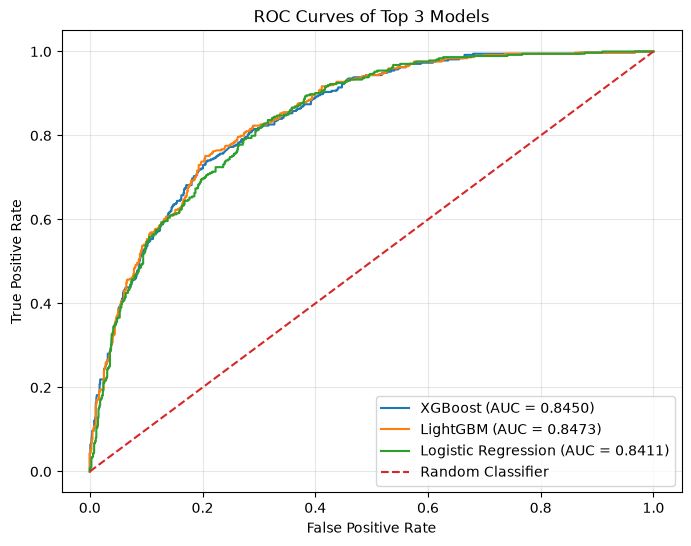

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, results in top3_predictions.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        results["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {results['auc']:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Top 3 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

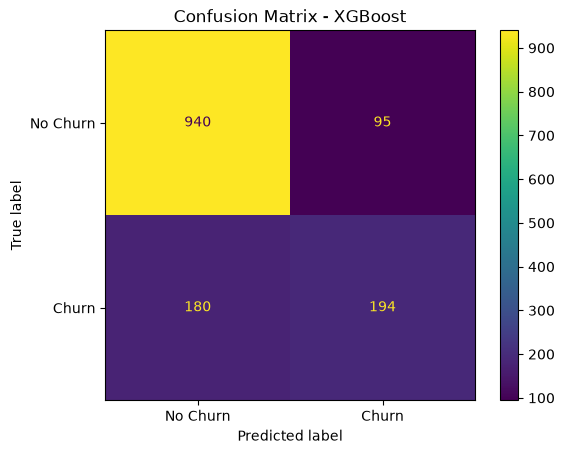

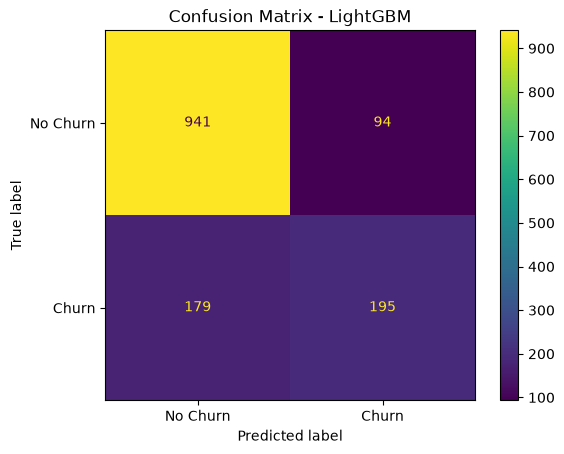

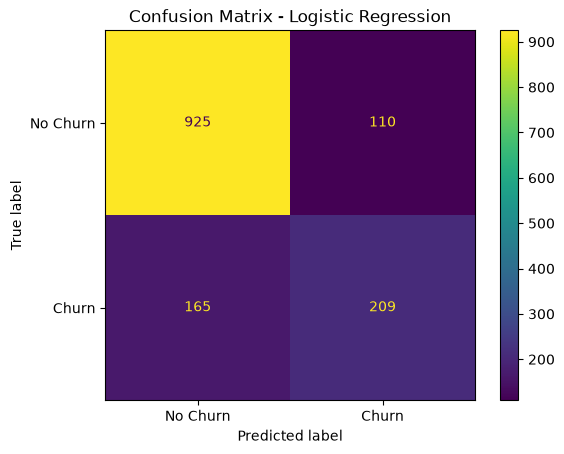

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, results in top3_predictions.items():

    ConfusionMatrixDisplay(
        confusion_matrix=results["cm"],
        display_labels=["No Churn", "Churn"]
    ).plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [106]:
# ==========================================
# TASK 10 - COST-SENSITIVE THRESHOLD SELECTION
# ==========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

FN_COST = 500
FP_COST = 50

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []
best_thresholds = {}

for name, model in top3_models.items():

    print(f"Finding threshold for {name}...")

    # Out-of-fold probabilities from TRAINING DATA ONLY
    oof_prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=5,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    model_costs = []

    for threshold in thresholds:

        pred = (oof_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            pred
        ).ravel()

        cost = (
            FN_COST * fn +
            FP_COST * fp
        )

        model_costs.append({
            "Model": name,
            "Threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Cost": cost
        })

    model_costs_df = pd.DataFrame(model_costs)

    best_row = model_costs_df.loc[
        model_costs_df["Cost"].idxmin()
    ]

    best_thresholds[name] = best_row["Threshold"]

    threshold_results.append(best_row)


optimal_threshold_table = pd.DataFrame(
    threshold_results
)

display(optimal_threshold_table.round(3))

Finding threshold for XGBoost...
Finding threshold for LightGBM...
Finding threshold for Logistic Regression...


,Model,Threshold,TN,FP,FN,TP,Cost
5,XGBoost,0.10,2022,2117,81,1414,146350
2,LightGBM,0.07,1660,2479,40,1455,143950
3,Logistic Regression,0.08,1855,2284,66,1429,147200


In [107]:
# ==========================================
# APPLY TRAINING-SELECTED THRESHOLDS TO TEST
# ==========================================

cost_test_results = []

for name, results in top3_predictions.items():

    threshold = best_thresholds[name]

    y_pred_cost = (
        results["prob"] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_cost
    ).ravel()

    total_cost = (
        FN_COST * fn +
        FP_COST * fp
    )

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    cost_test_results.append({
        "Model": name,
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Total Cost ($)": total_cost
    })


cost_comparison = pd.DataFrame(
    cost_test_results
).sort_values(
    "Total Cost ($)"
)

display(cost_comparison.round(4))

,Model,Threshold,FP,FN,TP,TN,Precision,Recall,F1-score,Total Cost ($)
2,Logistic Regression,0.08,566,12,362,469,0.3901,0.9679,0.5561,34300
1,LightGBM,0.07,618,9,365,417,0.3713,0.9759,0.5380,35400
0,XGBoost,0.10,537,19,355,498,0.3980,0.9492,0.5608,36350


In [108]:
# ==========================================
# TASK 11 - INTENTIONAL DATA LEAKAGE
# WRONG APPROACH
# ==========================================

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# WRONG APPROACH:
# The preprocessor is fitted on the entire training set
# BEFORE cross-validation.
# Therefore, validation-fold information leaks into preprocessing.

X_train_leaked = preprocessor_fs.fit_transform(
    X_train,
    y_train
)

leaked_model = LogisticRegression(
    C=10,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

leaked_scores = cross_val_score(
    leaked_model,
    X_train_leaked,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("INCORRECT leaked approach:")
print(
    f"ROC-AUC = "
    f"{leaked_scores.mean():.4f} ± "
    f"{leaked_scores.std():.4f}"
)

INCORRECT leaked approach:
ROC-AUC = 0.8459 ± 0.0138


In [109]:
leakage_comparison = pd.DataFrame({
    "Approach": [
        "Incorrect - Preprocessing Before CV",
        "Correct - Pipeline Inside CV"
    ],
    "Mean ROC-AUC": [
        leaked_scores.mean(),
        correct_scores.mean()
    ],
    "Std ROC-AUC": [
        leaked_scores.std(),
        correct_scores.std()
    ]
})

display(leakage_comparison.round(4))

,Approach,Mean ROC-AUC,Std ROC-AUC
0,Incorrect - Preprocessing Before CV,0.8459,0.0138
1,Correct - Pipeline Inside CV,0.8459,0.0138


In [110]:
# ==========================================
# TASK 11 - INTENTIONAL LEAKAGE CHALLENGE
# Feature Selection BEFORE Cross-Validation
# ==========================================

import numpy as np
import pandas as pd

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline


# ------------------------------------------
# WRONG APPROACH
# Preprocessing + feature selection are fitted
# on ALL training data BEFORE CV
# ------------------------------------------

X_preprocessed_leaked = preprocessor_fs.fit_transform(
    X_train,
    y_train
)

leaked_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

X_selected_leaked = leaked_selector.fit_transform(
    X_preprocessed_leaked,
    y_train
)

leaked_model = LogisticRegression(
    C=10,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

leaked_scores_fs = cross_val_score(
    leaked_model,
    X_selected_leaked,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)


# ------------------------------------------
# CORRECT APPROACH
# Everything is fitted INSIDE each CV fold
# ------------------------------------------

correct_pipeline_fs = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=20
    )),

    ("model", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

correct_scores_fs = cross_val_score(
    correct_pipeline_fs,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)


# ------------------------------------------
# COMPARISON
# ------------------------------------------

leakage_comparison_fs = pd.DataFrame({
    "Approach": [
        "Incorrect - Feature Selection Before CV",
        "Correct - Feature Selection Inside Pipeline"
    ],

    "Mean ROC-AUC": [
        leaked_scores_fs.mean(),
        correct_scores_fs.mean()
    ],

    "Std ROC-AUC": [
        leaked_scores_fs.std(),
        correct_scores_fs.std()
    ]
})

display(leakage_comparison_fs.round(4))

,Approach,Mean ROC-AUC,Std ROC-AUC
0,Incorrect - Feature Selection Before CV,0.8431,0.0143
1,Correct - Feature Selection Inside Pipeline,0.8431,0.0150


In [111]:
# ==========================================
# REBUILD TASK 8 MODELS AFTER KERNEL RESTART
# ==========================================

from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


# 1. Tuned LightGBM - no imbalance handling
tuned_lightgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])


# 2. Tuned LightGBM + Class Weighting
balanced_lightgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])


# 3. Tuned LightGBM + SMOTE
smote_lightgbm = ImbPipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

print("Task 8 models rebuilt successfully.")

Task 8 models rebuilt successfully.



Tuned LightGBM
TN = 941
FP = 94
FN = 179
TP = 195


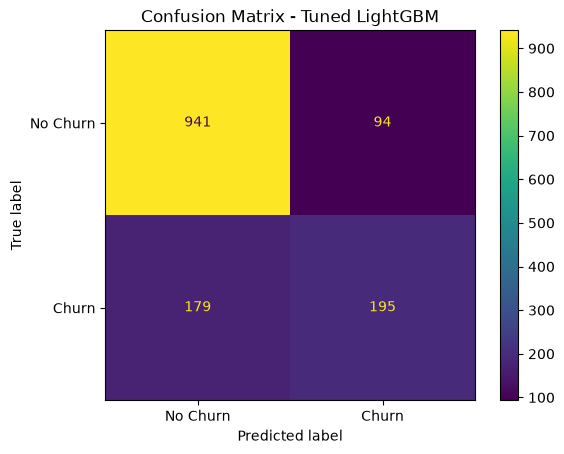


Balanced LightGBM
TN = 752
FP = 283
FN = 72
TP = 302


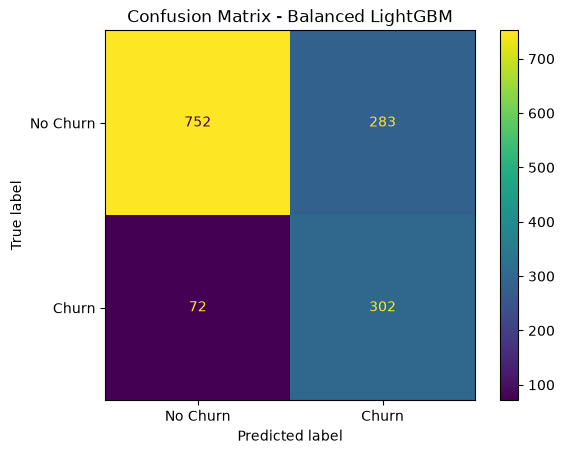


SMOTE LightGBM
TN = 812
FP = 223
FN = 95
TP = 279


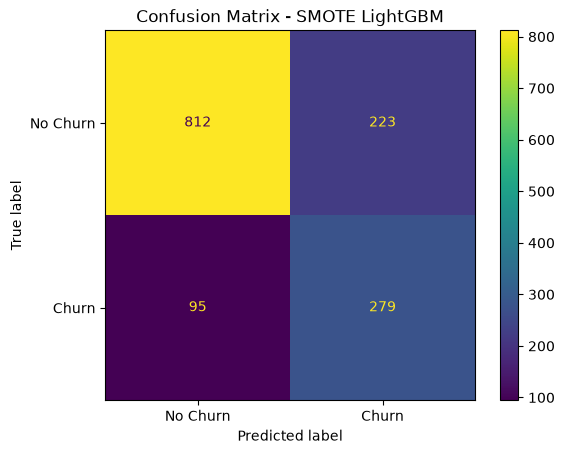

In [112]:
# ==========================================
# TASK 8 - CONFUSION MATRICES FOR
# CLASS IMBALANCE HANDLING METHODS
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


imbalance_models = {
    "Tuned LightGBM": tuned_lightgbm,
    "Balanced LightGBM": balanced_lightgbm,
    "SMOTE LightGBM": smote_lightgbm
}


imbalance_confusion_results = {}

for name, model in imbalance_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    imbalance_confusion_results[name] = cm

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")
    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    ).plot()

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()

In [113]:
# ==========================================
# TASK 12 - BEST PIPELINE FOR EACH MODEL
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# 1. Tuned Logistic Regression
final_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])


# 2. Tuned SVM
final_svm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", SVC(
        C=0.1,
        kernel="rbf",
        gamma="auto",
        probability=True,
        random_state=42
    ))
])


# 3. Tuned Random Forest
final_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])


# 4. Tuned XGBoost
final_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])


# 5. Tuned LightGBM
final_lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor_fs),

    ("model", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=20,
        subsample=0.70,
        colsample_bytree=1.00,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])


best_pipeline_models = {
    "Logistic Regression": final_logistic,
    "SVM": final_svm,
    "Random Forest": final_rf,
    "XGBoost": final_xgb,
    "LightGBM": final_lgbm
}

print("All five best pipelines rebuilt successfully.")

All five best pipelines rebuilt successfully.


In [114]:
# ==========================================
# TASK 12 - FINAL CROSS-VALIDATION COMPARISON
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

final_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

final_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

final_cv_results = []

for name, model in best_pipeline_models.items():

    print(f"Evaluating final pipeline: {name}...")

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=final_cv,
        scoring=final_scoring,
        n_jobs=1
    )

    final_cv_results.append({
        "Model": name,
        "Accuracy": result["test_accuracy"].mean(),
        "Precision": result["test_precision"].mean(),
        "Recall": result["test_recall"].mean(),
        "F1": result["test_f1"].mean(),
        "ROC-AUC": result["test_roc_auc"].mean(),
        "ROC-AUC Std": result["test_roc_auc"].std()
    })


final_model_comparison = pd.DataFrame(
    final_cv_results
).sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(final_model_comparison.round(4))

Evaluating final pipeline: Logistic Regression...
Evaluating final pipeline: SVM...


c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py

Evaluating final pipeline: Random Forest...
Evaluating final pipeline: XGBoost...
Evaluating final pipeline: LightGBM...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
0,XGBoost,0.8048,0.6718,0.5177,0.5846,0.8499,0.0117
1,LightGBM,0.8051,0.6765,0.5104,0.5814,0.8489,0.0110
2,Logistic Regression,0.8037,0.6557,0.5485,0.5968,0.8463,0.0128
3,Random Forest,0.7980,0.6972,0.4247,0.5273,0.8458,0.0103
4,SVM,0.7991,0.6730,0.4749,0.5563,0.8362,0.0132


In [115]:
pipeline_choices = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Feature Set": [
        "All features",
        "All features",
        "All features",
        "All features",
        "All features"
    ],

    "Hyperparameter Tuning": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ],

    "Imbalance Handling": [
        "None",
        "None",
        "None",
        "None",
        "None"
    ],

    "Reason": [
        "Highest ROC-AUC version",
        "Highest ROC-AUC version",
        "Highest ROC-AUC version",
        "Highest ROC-AUC version",
        "Highest ROC-AUC version"
    ]
})

display(pipeline_choices)

,Model,Feature Set,Hyperparameter Tuning,Imbalance Handling,Reason
0,Logistic Regression,All features,Yes,None,Highest ROC-AUC version
1,SVM,All features,Yes,None,Highest ROC-AUC version
2,Random Forest,All features,Yes,None,Highest ROC-AUC version
3,XGBoost,All features,Yes,None,Highest ROC-AUC version
4,LightGBM,All features,Yes,None,Highest ROC-AUC version


In [116]:
default_vs_tuned = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Default ROC-AUC": [
        0.8461,
        0.7989,
        0.8177,
        0.8229,
        0.8378
    ],

    "Tuned ROC-AUC": [
        0.8463,
        0.8362,
        0.8458,
        0.8499,
        0.8489
    ]
})

default_vs_tuned["Improvement"] = (
    default_vs_tuned["Tuned ROC-AUC"]
    - default_vs_tuned["Default ROC-AUC"]
)

display(
    default_vs_tuned
    .sort_values("Tuned ROC-AUC", ascending=False)
    .round(4)
)

,Model,Default ROC-AUC,Tuned ROC-AUC,Improvement
3,XGBoost,0.8229,0.8499,0.0270
4,LightGBM,0.8378,0.8489,0.0111
0,Logistic Regression,0.8461,0.8463,0.0002
2,Random Forest,0.8177,0.8458,0.0281
1,SVM,0.7989,0.8362,0.0373


In [117]:
# ==========================================
# TASK 12 - FINAL TEST PERFORMANCE
# BEST PIPELINE FOR EACH OF THE 5 MODELS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_test_results = []

for name, model in best_pipeline_models.items():

    print(f"Final test evaluation: {name}...")

    # Train using the full training set
    model.fit(X_train, y_train)

    # Final predictions on untouched test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


final_test_comparison = pd.DataFrame(
    final_test_results
).sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(final_test_comparison.round(4))

Final test evaluation: Logistic Regression...
Final test evaluation: SVM...


c:\Users\Extreme\Desktop\Donia\ML_Assignment_1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Final test evaluation: Random Forest...
Final test evaluation: XGBoost...
Final test evaluation: LightGBM...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.8062,0.6747,0.5214,0.5882,0.8473
1,XGBoost,0.8048,0.6713,0.5187,0.5852,0.8450
2,Logistic Regression,0.8048,0.6552,0.5588,0.6032,0.8411
3,Random Forest,0.7921,0.6753,0.4171,0.5157,0.8398
4,SVM,0.7921,0.6484,0.4733,0.5471,0.8299


In [118]:
# ==========================================
# TASK 12 - CV VS FINAL TEST PERFORMANCE
# ==========================================

cv_vs_test = final_model_comparison[
    ["Model", "ROC-AUC"]
].copy()

cv_vs_test = cv_vs_test.rename(
    columns={"ROC-AUC": "CV ROC-AUC"}
)

cv_vs_test = cv_vs_test.merge(
    final_test_comparison[
        ["Model", "ROC-AUC"]
    ].rename(
        columns={"ROC-AUC": "Test ROC-AUC"}
    ),
    on="Model"
)

cv_vs_test["Difference (Test - CV)"] = (
    cv_vs_test["Test ROC-AUC"]
    - cv_vs_test["CV ROC-AUC"]
)

cv_vs_test = cv_vs_test.sort_values(
    "CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(cv_vs_test.round(4))

,Model,CV ROC-AUC,Test ROC-AUC,Difference (Test - CV)
0,XGBoost,0.8499,0.8450,-0.0048
1,LightGBM,0.8489,0.8473,-0.0016
2,Logistic Regression,0.8463,0.8411,-0.0052
3,Random Forest,0.8458,0.8398,-0.0060
4,SVM,0.8362,0.8299,-0.0062
